<h1 align="center">Física Computacional</h1>
<h1 align="center">Semestre 2025-4</h1>

<h2>Sergio A. Alcalá Corona</h2>
<h2>Rodrigo Vega Vilchis</h2>

---
### Alumno: Juan Alexis Hernández Hernández
---

<h1 align="center">Práctica 6. Metodos numéricos para Ecuaciones Diferenciales Parciales y simulacion de Procesos Aleatorios</h1>

In [4]:
import math as mt
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import scipy as sp

### **1. Ecuación de Poisson para un potencial electrostático**: La *ecuación de Poisson* gobierna el potencial electrostático en presencia de una densidad de carga $\rho$:

$$
\nabla^2 \phi = -\frac{\rho}{\varepsilon_0}
$$

### Aquí $\varepsilon_0$ es la permitividad del espacio vacío (asumiendo que estamos en el vacío). Ahora, considera el siguiente sistema que consiste en una caja cuadrada de $1$ metro de lado, con paredes conductoras conectadas a tierra a $0$ volts:

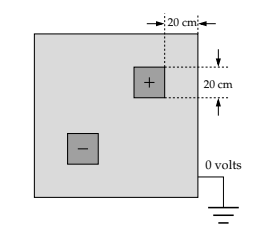

### Dentro de la caja hay dos cargas cuadradas de $20 \text{ cm}$ de lado, una positiva y otra negativa; colocadas a $20 \text{ cm}$ de las paredes de la caja. La densidad de carga de ambas es uniforme y tiene un valor de $\pm1\ \text{cm}^{-2}$ respectivamente. Para simplificar, considere el sistema en dos dimensiones.

#### **(a)** Escribe un programa para calcular el potencial $\phi$ en una cuadrícula de puntos dentro de la caja usando el *método de relajación*.

In [3]:
# Definimos el laplaciano
def laplaciano(phi,x,y,h):
    return 1/(h**2) * (phi(x+h,y) + phi(x-h,y) + phi(x,y+h) + phi(x,y-h) - 4*phi(x,y) )

In [4]:
def para(x,y):
    return x**2 + y**2

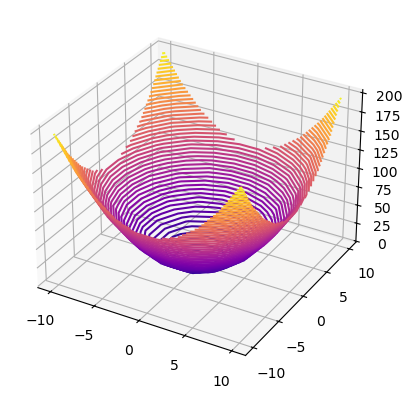

In [5]:
X = np.linspace(-10,10,10)
Y = np.linspace(-10,10,10)

x,y = np.meshgrid(X,Y)
z = para(x,y)

from mpl_toolkits import mplot3d

fig = pl.figure()
ax = pl.axes(projection='3d')
ax.contour3D(x,y,z,50,cmap='plasma')

In [6]:
# Ahora sí, calculemos el laplaciano
h = 0.01
laplaciano(para,x,y,h)

array([[4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.]])

In [7]:
# Vamos a resolver la ecuación de Laplace (a través del método de relajación)
def sol_eclaplace(phi,x,y,h): # sol_eclaplace = phi_n
    return -1/4 * (phi(x+h,y) + phi(x-h,y) + phi(x,y+h) + phi(x,y-h))

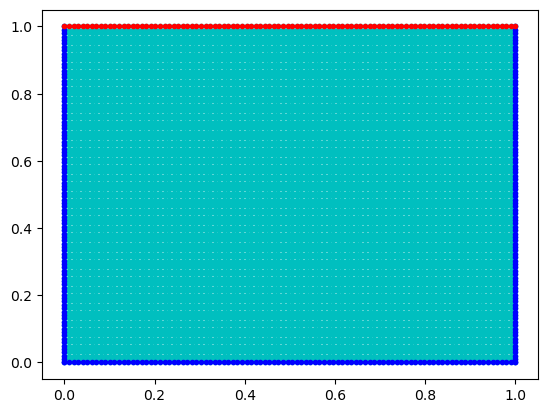

In [63]:
# Definimos una serie de puntos
limit = 1
puntos = 100
X = np.linspace(0,limit,puntos)
Y = np.linspace(0,limit,puntos)
x,y = np.meshgrid(X,Y)

pl.plot(x,y,'c.')
pl.plot(x[0],y[0],'b.')
pl.plot(x[:,0],y[:,0],'b.')
pl.plot(x[:,len(x)-limit],y[:,0],'b.')
pl.plot(x[0],y[len(x)-limit],'r.')

In [203]:
# En lugar del meshgrid vamos a trabajarlo como una matriz

# prueba
dim = 10
M = np.zeros((dim,dim))
M[:,0] = 1
M[0,:] = 9
M

array([[9., 9., 9., 9., 9., 9., 9., 9., 9., 9.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [289]:
# INTENTO BUENO vie 8/ago
V = 1.25

N = 10
dom = np.zeros((N,N))
phi_n = np.zeros((N,N))

phi_n[0,:] = V
phi_n

array([[1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

In [296]:
V = 1.25

N = 10
dom = np.zeros((N,N))
phi_n = np.zeros((N,N))

phi_n[0,:] = V



for m in range(100): # Para estabilizar la x
    for i in range(N-1):
        for k in range(100): # Para estabilizar la y
            for j in range(N-1):
                # if i==0 or i==N or j==0 or j==N: # Condiciones de frontera
                if i==0 or j==0: # Condiciones de frontera
                    continue
                    # phi_n[i,j] = phi_n[i,j] # i.e. nada debe cambiar ahí
                else:
                    phi_n[i,j] = 1/4 * (phi_n[i+1,i] + phi_n[i-1,j] + phi_n[i,j+1] + phi_n[i,j-1])

phi_n

array([[1.25000000e+00, 1.25000000e+00, 1.25000000e+00, ...,
        1.25000000e+00, 1.25000000e+00, 1.25000000e+00],
       [0.00000000e+00, 6.12727133e-01, 7.76906873e-01, ...,
        7.76906873e-01, 6.12727133e-01, 0.00000000e+00],
       [0.00000000e+00, 4.24126990e-01, 5.85166083e-01, ...,
        5.85166083e-01, 4.24126990e-01, 0.00000000e+00],
       ...,
       [0.00000000e+00, 2.92304074e-09, 4.52561535e-09, ...,
        4.52561535e-09, 2.92304074e-09, 0.00000000e+00],
       [0.00000000e+00, 1.25213481e-09, 2.08549851e-09, ...,
        2.08549851e-09, 1.25213481e-09, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [339]:
V = 1.25
N = 100

exactitud = 1e-5
error = 1.0

phi_n = np.zeros((N,N))
phi_n[0,:] = V

phin_1 = np.copy(phi_n)

while error > exactitud:
    for i in range(N-1):
        for j in range(N-1):
            # if i==0 or i==N or j==0 or j==N: # Condiciones de frontera
            if i==0 or j==0: # Condiciones de frontera
                continue
                # phi_n[i,j] = phi_n[i,j] # i.e. nada debe cambiar ahí
            else:
                phi_n[i,j] = 1/4 * (phin_1[i+1,i] + phin_1[i-1,j] + phin_1[i,j+1] + phin_1[i,j-1])
    error = np.max(np.abs(phin_1 - phi_n))
    phin_1,phi_n = phi_n,phin_1
    # phin_1 = phi_n # El anterior es el nuevo actual
    # phi_n = phin_1 # El "actual" es el nuevo anterior
                
print(phi_n)

[[1.25000000e+00 1.25000000e+00 1.25000000e+00 ... 1.25000000e+00
  1.25000000e+00 1.25000000e+00]
 [0.00000000e+00 6.19765364e-01 7.85830966e-01 ... 7.85830966e-01
  6.19765364e-01 0.00000000e+00]
 [0.00000000e+00 4.43230824e-01 6.09933096e-01 ... 6.09933096e-01
  4.43230824e-01 0.00000000e+00]
 ...
 [0.00000000e+00 2.87528039e-03 4.38469194e-03 ... 4.38469194e-03
  2.87528039e-03 0.00000000e+00]
 [0.00000000e+00 1.22263189e-03 2.01555713e-03 ... 2.01555713e-03
  1.22263189e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


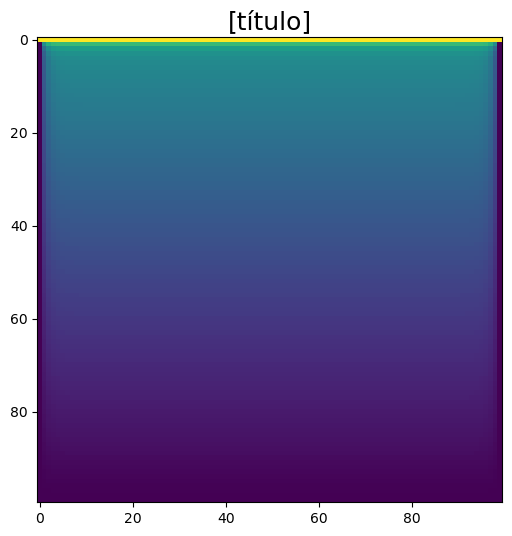

In [340]:
pl.figure(figsize=(6,8))
pl.title("[título]",size=18)
pl.imshow(phi_n)

In [48]:
# for i in range(N+1):
#     for j in range(N+1):
#         if i==0:# or i==N or j==0 or j==N:
#             print('x:',i,'y:',j,'pared izquierda')
#         elif i==N:
#             print('x:',i,'y:',j,'pared derecha')
#         elif j==0:
#             print('x:',i,'y:',j,'pared abajo')
#         elif j==N:
#             print('x:',i,'y:',j,'pared arriba')
#         else:
#             print('x:',i,'y:',j,'lo demás')

#### **(b)** Realiza un *gráfico de densidad* del resultado.

#### Trabaja en unidades donde $\varepsilon_0 = 1$ y continúa la iteración hasta que tu solución para el potencial eléctrico cambie en menos de $10^{-6}\ \text{V}$ por paso en cada punto de la cuadrícula.

### **2. Difusión térmica en la corteza terrestre**: Un ejemplo clásico de un problema de difusión con una condición de frontera variable en el tiempo es la *difusión de calor* hacia la corteza terrestre, a medida que la temperatura superficial varía con las estaciones. Supongamos que la temperatura media diaria en un punto particular de la superficie varía como:

$$
T_0(t) = A + B \sin\left(\frac{2\pi t}{\tau}\right),
$$

### donde $\tau = 365$ días, $A = 10^\circ \text{C}$ y $B = 12^\circ \text{C}$.

### A una profundidad de $20 \text{ m}$ bajo la superficie, casi toda la variación anual de temperatura se mantiene constante y la temperatura se mantiene, aproximadamente, en $11^\circ \text{C}$ (que es mayor que la temperatura superficial media de $10^\circ \text{C}$; la temperatura aumenta con la profundidad debido al calentamiento del núcleo caliente del planeta). La difusividad térmica de la corteza terrestre varía ligeramente de un lugar a otro, pero para nuestros propósitos la consideraremos constante con un valor $D = 0.1\ \text{m}^2\text{día}^{-1}$.

#### Escribe un programa, para calcular el perfil de temperatura de la corteza en función de la profundidad hasta $20 \text{ m}$ y el tiempo hasta $10$ años. Comienza con una temperatura en todas partes igual a $10^\circ \text{C}$, excepto en la superficie y el punto más profundo. Elige valores para el número de puntos de la cuadrícula y el intervalo de tiempo $h$. Luego, ejecuta el programa durante los primeros nueve años simulados para que se estabilice en el patrón que alcance. Para el décimo y último año, traza cuatro perfiles de temperatura tomados a intervalos de tres meses en un solo gráfico para ilustrar cómo cambia la temperatura en función de la profundidad y el tiempo.


### **3. Solución FTCS (***forward-time centered-space***) de la ecuación de onda**: Considera una cuerda de piano de longitud $L$, inicialmente en reposo. En el instante $t = 0$, el martillo del piano golpea la cuerda a una distancia $d$ del extremo de la cuerda:

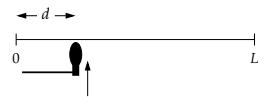

### La cuerda vibra al ser golpeada, excepto en los extremos $x = 0$ y $x = L$, donde se mantiene fija.

#### Escribe un programa que utilice el **método** de ***espacio centrado en tiempo hacia adelante*** (*forward-time centered-space*) **FTCS**, para resolver el **conjunto completo** de ecuaciones (diferenciales ordinarias) simultáneas de primer orden, para el caso $v = 100~\text{m/s}$, con la condición inicial de que $\phi(x) = 0$ en todas partes excepto cuando la velocidad $\psi(x) = \dot{\phi}$ es distinta de cero, i.e.:

$$
\psi(x) = C \cdot \frac{x(L - x)}{L^2} \cdot \exp\left[-\frac{(x - d)^2}{2\sigma^2}\right],
$$

#### donde $L = 1 \text{ m}$, $d = 10 \text{ cm}$, $C = 1  \text{ m/s}$ y $\sigma = 0.3 \text{ m}$. Elige un valor razonable para $h$ (por ejemplo $h = 10^{-6} \text{ s}$).

### **4. Lanzando dados**


#### **(a)** Escribe un programa que genere e imprima dos números aleatorios entre $1$ y $6$ para simular el lanzamiento de dos dados.

#### **(b)** Modifica tu programa para simular el lanzamiento de dos dados un millón de veces y cuenta el número de veces que obtienes un doble seis. Divide entre un millón para obtener la *fracción* de veces que obtienes un doble seis. Deberías obtener un resultado cercano a: $\frac{1}{36}$.

### **5. Movimiento browniano y caminatas aleatorias**: El *movimiento browniano* es el movimiento de una partícula (por ejemplo de humo o polvo) en un gas, al chocar aleatoriamente con las moléculas del propio gas.

### En una simulación computacional en dos dimensiones (2D) se puede considerar que dicha partícula está confinada en una cuadrícula (o red cuadrada) de $L \times L$ cuadrados de lado, de modo que su posición puede representarse mediante dos enteros $x$, $y$ y comienza en el centro de la cuadrícula. Así, en cada paso de la simulación, se elige una dirección aleatoria (arriba, abajo, izquierda o derecha) y la partícula se mueve un paso en esa dirección. Este proceso se denomina *caminata aleatoria*. Realiza una simulación computacional del movimiento browniano, como se indica a continuación.

### Para comenzar, considera un caminante aleatorio en **una dimensión** (1D), el cual da un paso (de longitud $l$) hacia la derecha con probabilidad $p$ o uno a la izquierda con probabilidad $q = 1 - p$.



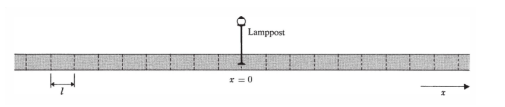

#### **(a)** Escribe un programa que simule una *caminata aleatoria* de $N$ pasos y haz una gráfica de las posiciones de la caminata vs el tiempo. Asimismo, grafica un histograma de la frecuencia de dichas posiciones. Puedes considerar $l = 1$, para simplificar las cosas.

#### **(b)** Ahora, convierte tu programa del ejercicio anterior en una función y úsala para generar 100 caminatas aleatorias. Haz una sola gráfica de las posiciones de todas las caminatas vs el tiempo $t$. Asimismo, grafica un único histograma de la frecuencia de las posiciones de todas las caminatas. **¿Qué es lo que observas?, ¿cuál es la diferencia con lo que obtuviste en el ejercicio anterior?**

#### **(c)** Finalmente, generaliza tu programa para simular una (o varias) caminatas aleatorias en 2D y 3D, y úsalas para graficar las posiciones $(x, y)$ o $(x, y, z)$ de una o varias caminatas.

### ** **Problema opcional: Área de un círculo unitario (2 puntos extra)**: Estima el área de un círculo de radio unitario utilizando el método de Monte Carlo.


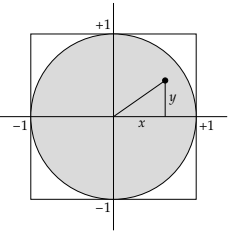

### El área del círculo, el área sombreada arriba, viene dada por la integral:

$$
I = \iint_{-1}^{+1} f(x, y) \, dx \, dy,
$$

### donde $f(x,y) = 1$ en todo el interior del círculo y cero en el exterior. En otras palabras,

$$f(x, y) = \begin{cases} 1 & \text{si } x^2 + y^2 \leq 1, \\ 0 & \text{en caso contrario}. \end{cases}$$

### Así, si no conociéramos el área del círculo, podríamos calcularla mediante integración de Monte Carlo. Habría que generar un conjunto de $N$ puntos aleatorios $(x, y)$, donde tanto $x$ como $y$ están en el rango de $-1$ a $1$. Con lo que la aproximación quedaría como:

$$
I \approx \frac{4}{N} \sum_{i=1}^{N} f(x_i, y_i)
$$